# Superstore Sales Analysis
### Exploratory Data Analysis on the Sample Superstore Retail Dataset

**Objective:** Explore the Sample Superstore dataset to understand sales and profit performance across products, regions, customer segments, and time, and to surface actionable business insights (e.g. which categories/discount levels are driving losses).

**Dataset:** Sample - Superstore (retail order-level transactions: Sales, Profit, Quantity, Discount, Region, Category, Ship Mode, etc.)

**Workflow:**
1. Import libraries & load data
2. Data quality checks (missing values, duplicates, dtypes)
3. Data cleaning & feature engineering (dates, shipping duration)
4. Key business metrics (KPIs)
5. Category / Sub-Category / Product analysis
6. Regional, State & Segment analysis
7. Shipping mode & discount analysis
8. Loss-making orders analysis
9. Time-series trend analysis
10. Visualizations
11. Correlation analysis
12. Key findings & recommendations

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import os

In [2]:
os.getcwd()

'/home/claude/project'

In [3]:
os.listdir()

['annotated_notebook.ipynb', 'base_notebook.ipynb', 'Sample - Superstore.csv']

## 2. Load the Dataset

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding='cp1252')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 2.1 Dataset Shape

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 21


In [7]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [9]:
os.getcwd()
os.listdir()
df.shape
df.columns.tolist()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## 3. Data Quality Checks
### 3.1 Missing Values

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing[missing["Missing Values"] > 0]

,Missing Values,Missing %


### 3.2 Duplicate Rows

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
df[df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


### 3.3 Categorical Columns Overview

In [14]:
categorical_cols = df.select_dtypes(include=["object", "str"]).columns

In [15]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].unique()[:20])


--- Order ID ---
Unique values: 5009
<StringArray>
['CA-2016-152156', 'CA-2016-138688', 'US-2015-108966', 'CA-2014-115812',
 'CA-2017-114412', 'CA-2016-161389', 'US-2015-118983', 'CA-2014-105893',
 'CA-2014-167164', 'CA-2014-143336', 'CA-2016-137330', 'US-2017-156909',
 'CA-2015-106320', 'CA-2016-121755', 'US-2015-150630', 'CA-2017-107727',
 'CA-2016-117590', 'CA-2015-117415', 'CA-2017-120999', 'CA-2016-101343']
Length: 20, dtype: str

--- Order Date ---
Unique values: 1237
<StringArray>
[ '11/8/2016',  '6/12/2016', '10/11/2015',   '6/9/2014',  '4/15/2017',
  '12/5/2016', '11/22/2015', '11/11/2014',  '5/13/2014',  '8/27/2014',
  '12/9/2016',  '7/16/2017',  '9/25/2015',  '1/16/2016',  '9/17/2015',
 '10/19/2017',  '12/8/2016', '12/27/2015',  '9/10/2017',  '7/17/2016']
Length: 20, dtype: str

--- Ship Date ---
Unique values: 1334
<StringArray>
['11/11/2016',  '6/16/2016', '10/18/2015',  '6/14/2014',  '4/20/2017',
 '12/10/2016', '11/26/2015', '11/18/2014',  '5/15/2014',   '9/1/2014',
 '12

### 3.4 Numerical Columns Overview

In [16]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='str')

In [17]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


## 4. Data Cleaning & Feature Engineering
### 4.1 Convert Date Columns to `datetime`

In [18]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,11/8/2016,11/11/2016
1,11/8/2016,11/11/2016
2,6/12/2016,6/16/2016
3,10/11/2015,10/18/2015
4,10/11/2015,10/18/2015


In [19]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    str
Ship Date     str
dtype: object

In [20]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check data types
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

### 4.2 Re-check Missing Values

In [21]:
# Check missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [22]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


### 4.3 Date Range Covered

In [23]:
print("Minimum Order Date:", df['Order Date'].min())
print("Maximum Order Date:", df['Order Date'].max())

print("Minimum Ship Date:", df['Ship Date'].min())
print("Maximum Ship Date:", df['Ship Date'].max())

Minimum Order Date: 2014-01-03 00:00:00
Maximum Order Date: 2017-12-30 00:00:00
Minimum Ship Date: 2014-01-07 00:00:00
Maximum Ship Date: 2018-01-05 00:00:00


### 4.4 Create Date-Based Features (Year, Month, Quarter) & Shipping Duration

In [24]:
# Create date-based features

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.quarter

# Calculate shipping duration
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,7


In [25]:
df[['Order Date',
    'Ship Date',
    'Order Year',
    'Order Month',
    'Order Month Name',
    'Order Quarter',
    'Shipping Days']].head(10)

,Order Date,Ship Date,Order Year,Order Month,Order Month Name,Order Quarter,Shipping Days
0,2016-11-08,2016-11-11,2016,11,November,4,3
1,2016-11-08,2016-11-11,2016,11,November,4,3
2,2016-06-12,2016-06-16,2016,6,June,2,4
3,2015-10-11,2015-10-18,2015,10,October,4,7
4,2015-10-11,2015-10-18,2015,10,October,4,7
5,2014-06-09,2014-06-14,2014,6,June,2,5
6,2014-06-09,2014-06-14,2014,6,June,2,5
7,2014-06-09,2014-06-14,2014,6,June,2,5
8,2014-06-09,2014-06-14,2014,6,June,2,5
9,2014-06-09,2014-06-14,2014,6,June,2,5


### 4.5 Final Cleaned Dataset Overview

In [26]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 9994
Columns: 26
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9994 non-null   int64         
 1   Order ID          9994 non-null   str           
 2   Order Date        9994 non-null   datetime64[us]
 3   Ship Date         9994 non-null   datetime64[us]
 4   Ship Mode         9994 non-null   str           
 5   Customer ID       9994 non-null   str           
 6   Customer Name     9994 non-null   str           
 7   Segment           9994 non-null   str           
 8   Country           9994 non-null   str           
 9   City              9994 non-null   str           
 10  State             9994 non-null   str           
 11  Postal Code       9994 non-null   int64         
 12  Region            9994 non-null   str           
 13  Product ID        9994 non-null   str           
 14  Category    

In [27]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2016-04-30 00:07:12.259355,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,2016-05-03 23:06:58.571142,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
Postal Code,9994.0,55190.379428,1040.0,23223.0,56430.5,90008.0,99301.0,32063.69335
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108
Order Year,9994.0,2015.722233,2014.0,2015.0,2016.0,2017.0,2017.0,1.123555
Order Month,9994.0,7.809686,1.0,5.0,9.0,11.0,12.0,3.284654


## 5. Key Business Metrics (KPIs)

In [28]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
total_products = df['Product ID'].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity Sold: 37873
Total Orders: 5009
Total Customers: 793
Total Products: 1862


### 5.1 Overall Profit Margin

In [29]:
profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", round(profit_margin, 2), "%")

Overall Profit Margin: 12.47 %


### 5.2 Average Order Value

In [30]:
average_order_value = total_sales / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 458.61


### 5.3 Average Profit per Order

In [31]:
average_profit_per_order = total_profit / total_orders

print("Average Profit per Order:", round(average_profit_per_order, 2))

Average Profit per Order: 57.18


## 6. Category-Level Analysis

In [32]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [33]:
category_profit = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [34]:
category_analysis = (
    df.groupby('Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Sales', ascending=False)
)

category_analysis

,Sales,Profit,Quantity,Orders
Category,,,,
Technology,836154.0330,145454.9481,6939,1544
Furniture,741999.7953,18451.2728,8028,1764
Office Supplies,719047.0320,122490.8008,22906,3742


In [35]:
category_analysis['Profit Margin %'] = (
    category_analysis['Profit'] /
    category_analysis['Sales']
) * 100

category_analysis

,Sales,Profit,Quantity,Orders,Profit Margin %
Category,,,,,
Technology,836154.0330,145454.9481,6939,1544,17.395712
Furniture,741999.7953,18451.2728,8028,1764,2.486695
Office Supplies,719047.0320,122490.8008,22906,3742,17.035158


## 7. Sub-Category & Product-Level Analysis

In [36]:
subcategory_analysis = (
    df.groupby('Sub-Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Sales', ascending=False)
)

subcategory_analysis

,Sales,Profit,Quantity,Orders
Sub-Category,,,,
Phones,330007.0540,44515.7306,3289,814
Chairs,328449.1030,26590.1663,2356,576
Storage,223843.6080,21278.8264,3158,777
Tables,206965.5320,-17725.4811,1241,307
Binders,203412.7330,30221.7633,5974,1316
Machines,189238.6310,3384.7569,440,112
Accessories,167380.3180,41936.6357,2976,718
Copiers,149528.0300,55617.8249,234,68
Bookcases,114879.9963,-3472.5560,868,224


In [37]:
top10_subcategories_sales = (
    subcategory_analysis
    .sort_values('Sales', ascending=False)
    .head(10)
)

top10_subcategories_sales

,Sales,Profit,Quantity,Orders
Sub-Category,,,,
Phones,330007.0540,44515.7306,3289,814
Chairs,328449.1030,26590.1663,2356,576
Storage,223843.6080,21278.8264,3158,777
Tables,206965.5320,-17725.4811,1241,307
Binders,203412.7330,30221.7633,5974,1316
Machines,189238.6310,3384.7569,440,112
Accessories,167380.3180,41936.6357,2976,718
Copiers,149528.0300,55617.8249,234,68
Bookcases,114879.9963,-3472.5560,868,224


In [38]:
bottom10_subcategories_profit = (
    subcategory_analysis
    .sort_values('Profit', ascending=True)
    .head(10)
)

bottom10_subcategories_profit

,Sales,Profit,Quantity,Orders
Sub-Category,,,,
Tables,206965.5320,-17725.4811,1241,307
Bookcases,114879.9963,-3472.5560,868,224
Supplies,46673.5380,-1189.0995,647,187
Fasteners,3024.2800,949.5182,914,215
Machines,189238.6310,3384.7569,440,112
Labels,12486.3120,5546.2540,1400,346
Art,27118.7920,6527.7870,3000,731
Envelopes,16476.4020,6964.1767,906,249
Furnishings,91705.1640,13059.1436,3563,877


In [39]:
top10_products_sales = (
    df.groupby(['Product ID', 'Product Name'])
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .sort_values('Sales', ascending=False)
      .head(10)
)

top10_products_sales

,,Sales,Profit,Quantity
Product ID,Product Name,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27


In [40]:
top10_products_profit = (
    df.groupby(['Product ID', 'Product Name'])
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .sort_values('Profit', ascending=False)
      .head(10)
)
top10_products_profit

,,Sales,Profit,Quantity
Product ID,Product Name,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38
TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12
TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11
TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11
TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24
OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13


In [41]:
bottom10_products_profit = (
    df.groupby(['Product ID', 'Product Name'])
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .sort_values('Profit', ascending=True)
      .head(10)
)

bottom10_products_profit

,,Sales,Profit,Quantity
Product ID,Product Name,,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19


## 8. Regional & State-Level Analysis

In [42]:
region_analysis = (
    df.groupby('Region')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Sales', ascending=False)
)

region_analysis

,Sales,Profit,Quantity,Orders
Region,,,,
West,725457.8245,108418.4489,12266,1611
East,678781.2400,91522.7800,10618,1401
Central,501239.8908,39706.3625,8780,1175
South,391721.9050,46749.4303,6209,822


In [43]:
region_analysis['Profit Margin %'] = (
    region_analysis['Profit'] /
    region_analysis['Sales']
) * 100

region_analysis

,Sales,Profit,Quantity,Orders,Profit Margin %
Region,,,,,
West,725457.8245,108418.4489,12266,1611,14.944831
East,678781.2400,91522.7800,10618,1401,13.483399
Central,501239.8908,39706.3625,8780,1175,7.921629
South,391721.9050,46749.4303,6209,822,11.934342


In [44]:
state_analysis = (
    df.groupby('State')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Sales', ascending=False)
)

state_analysis.head(10)

,Sales,Profit,Quantity,Orders
State,,,,
California,457687.6315,76381.3871,7667,1021
New York,310876.2710,74038.5486,4224,562
Texas,170188.0458,-25729.3563,3724,487
Washington,138641.2700,33402.6517,1883,256
Pennsylvania,116511.9140,-15559.9603,2153,288
Florida,89473.7080,-3399.3017,1379,200
Illinois,80166.1010,-12607.8870,1845,276
Ohio,78258.1360,-16971.3766,1759,236
Michigan,76269.6140,24463.1876,946,117


In [45]:
state_analysis.sort_values(
    'Profit',
    ascending=False
).head(10)

,Sales,Profit,Quantity,Orders
State,,,,
California,457687.6315,76381.3871,7667,1021
New York,310876.2710,74038.5486,4224,562
Washington,138641.2700,33402.6517,1883,256
Michigan,76269.6140,24463.1876,946,117
Virginia,70636.7200,18597.9504,893,115
Indiana,53555.3600,18382.9363,578,73
Georgia,49095.8400,16250.0433,705,91
Kentucky,36591.7500,11199.6966,523,61
Minnesota,29863.1500,10823.1874,331,44


In [46]:
state_analysis.sort_values(
    'Profit',
    ascending=True
).head(10)

,Sales,Profit,Quantity,Orders
State,,,,
Texas,170188.0458,-25729.3563,3724,487
Ohio,78258.1360,-16971.3766,1759,236
Pennsylvania,116511.9140,-15559.9603,2153,288
Illinois,80166.1010,-12607.8870,1845,276
North Carolina,55603.1640,-7490.9122,983,136
Colorado,32108.1180,-6527.8579,693,79
Tennessee,30661.8730,-5341.6936,681,91
Arizona,35282.0010,-3427.9246,862,108
Florida,89473.7080,-3399.3017,1379,200


## 9. Customer Segment Analysis

In [47]:
segment_analysis = (
    df.groupby('Segment')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique'),
          Customers=('Customer ID', 'nunique')
      )
      .sort_values('Sales', ascending=False)
)

segment_analysis

,Sales,Profit,Quantity,Orders,Customers
Segment,,,,,
Consumer,1.161401e+06,134119.2092,19521,2586,409
Corporate,7.061464e+05,91979.1340,11608,1514,236
Home Office,4.296531e+05,60298.6785,6744,909,148


In [48]:
segment_analysis['Profit Margin %'] = (
    segment_analysis['Profit'] /
    segment_analysis['Sales']
) * 100

segment_analysis

,Sales,Profit,Quantity,Orders,Customers,Profit Margin %
Segment,,,,,,
Consumer,1.161401e+06,134119.2092,19521,2586,409,11.548050
Corporate,7.061464e+05,91979.1340,11608,1514,236,13.025506
Home Office,4.296531e+05,60298.6785,6744,909,148,14.034269


## 10. Shipping Mode Analysis

In [49]:
shipmode_analysis = (
    df.groupby('Ship Mode')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique'),
          Avg_Shipping_Days=('Shipping Days', 'mean')
      )
      .sort_values('Sales', ascending=False)
)

shipmode_analysis

,Sales,Profit,Quantity,Orders,Avg_Shipping_Days
Ship Mode,,,,,
Standard Class,1.358216e+06,164088.7875,22797,2994,5.006535
Second Class,4.591936e+05,57446.6354,7423,964,3.238046
First Class,3.514284e+05,48969.8399,5693,787,2.182705
Same Day,1.283631e+05,15891.7589,1960,264,0.044199


In [50]:
shipmode_analysis = (
    df.groupby('Ship Mode')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique'),
          Avg_Shipping_Days=('Shipping Days', 'mean')
      )
      .sort_values('Sales', ascending=False)
)

shipmode_analysis

,Sales,Profit,Quantity,Orders,Avg_Shipping_Days
Ship Mode,,,,,
Standard Class,1.358216e+06,164088.7875,22797,2994,5.006535
Second Class,4.591936e+05,57446.6354,7423,964,3.238046
First Class,3.514284e+05,48969.8399,5693,787,2.182705
Same Day,1.283631e+05,15891.7589,1960,264,0.044199


## 11. Discount Impact Analysis

In [51]:
discount_analysis = (
    df.groupby('Discount')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_index()
)

discount_analysis

,Sales,Profit,Quantity,Orders
Discount,,,,
0.00,1.087908e+06,320987.6032,18267,2644
0.10,5.436935e+04,9029.1770,373,89
0.15,2.755852e+04,1418.9915,198,51
0.20,7.645944e+05,90337.3060,13660,2407
0.30,1.032267e+05,-10369.2774,849,211
0.32,1.449346e+04,-2391.1377,105,27
0.40,1.164178e+05,-23057.0504,786,185
0.45,5.484974e+03,-2493.1111,45,10
0.50,5.891854e+04,-20506.4281,241,64


In [52]:
discount_analysis['Profit Margin %'] = (
    discount_analysis['Profit'] /
    discount_analysis['Sales']
) * 100

discount_analysis

,Sales,Profit,Quantity,Orders,Profit Margin %
Discount,,,,,
0.00,1.087908e+06,320987.6032,18267,2644,29.505019
0.10,5.436935e+04,9029.1770,373,89,16.607108
0.15,2.755852e+04,1418.9915,198,51,5.149012
0.20,7.645944e+05,90337.3060,13660,2407,11.815063
0.30,1.032267e+05,-10369.2774,849,211,-10.045155
0.32,1.449346e+04,-2391.1377,105,27,-16.498047
0.40,1.164178e+05,-23057.0504,786,185,-19.805437
0.45,5.484974e+03,-2493.1111,45,10,-45.453472
0.50,5.891854e+04,-20506.4281,241,64,-34.804712


## 12. Loss-Making Orders Analysis

In [53]:
loss_making = df[df['Profit'] < 0]

print("Loss-making rows:", len(loss_making))
print("Total loss:", round(loss_making['Profit'].sum(), 2))

Loss-making rows: 1871
Total loss: -156131.29


In [54]:
loss_by_category = (
    loss_making.groupby('Category')['Profit']
    .sum()
    .sort_values()
)

loss_by_category

Category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64

## 13. Time-Series Trend Analysis
### 13.1 Monthly Sales & Profit

In [55]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
      .sum()
)

monthly_sales

Order Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


In [56]:
monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64

In [57]:
monthly_profit = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Profit']
      .sum()
)

monthly_profit.index = monthly_profit.index.to_timestamp()

monthly_profit.head()

Order Date
2014-01-01    2450.1907
2014-02-01     862.3084
2014-03-01     498.7299
2014-04-01    3488.8352
2014-05-01    2738.7096
Freq: MS, Name: Profit, dtype: float64

### 13.2 Yearly Performance

In [58]:
yearly_analysis = (
    df.groupby('Order Year')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

yearly_analysis

,Sales,Profit,Quantity,Orders
Order Year,,,,
2014,484247.4981,49543.9741,7581,969
2015,470532.5090,61618.6037,7979,1038
2016,609205.5980,81795.1743,9837,1315
2017,733215.2552,93439.2696,12476,1687


In [59]:
yearly_analysis['Profit Margin %'] = (
    yearly_analysis['Profit'] /
    yearly_analysis['Sales']
) * 100

yearly_analysis

,Sales,Profit,Quantity,Orders,Profit Margin %
Order Year,,,,,
2014,484247.4981,49543.9741,7581,969,10.231126
2015,470532.5090,61618.6037,7979,1038,13.095504
2016,609205.5980,81795.1743,9837,1315,13.426530
2017,733215.2552,93439.2696,12476,1687,12.743771


### 13.3 Quarterly Performance

In [60]:
quarterly_analysis = (
    df.groupby(['Order Year', 'Order Quarter'])
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

quarterly_analysis

,Order Year,Order Quarter,Sales,Profit,Quantity
0,2014,1,74447.7960,3811.2290,1028
1,2014,2,86538.7596,11204.0692,1523
2,2014,3,143633.2123,12804.7218,2159
3,2014,4,179627.7302,21723.9541,2871
4,2015,1,68851.7386,9264.9416,990
5,2015,2,89124.1870,12190.9224,1604
6,2015,3,130259.5752,16853.6194,2241
7,2015,4,182297.0082,23309.1203,3144
8,2016,1,93237.1810,11441.3708,1243
9,2016,2,136082.3010,16390.3394,2240


### 13.4 Shipping Duration by Ship Mode

In [61]:
shipping_analysis = (
    df.groupby('Ship Mode')
      .agg(
          Avg_Shipping_Days=('Shipping Days', 'mean'),
          Min_Shipping_Days=('Shipping Days', 'min'),
          Max_Shipping_Days=('Shipping Days', 'max'),
          Orders=('Order ID', 'nunique')
      )
)

shipping_analysis

,Avg_Shipping_Days,Min_Shipping_Days,Max_Shipping_Days,Orders
Ship Mode,,,,
First Class,2.182705,1,4,787
Same Day,0.044199,0,1,264
Second Class,3.238046,1,5,964
Standard Class,5.006535,3,7,2994


## 14. Export Cleaned Dataset

In [62]:
df.to_csv(
    'Superstore_Cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 15. Data Visualizations
Set up plotting style, then visualize the trends and comparisons uncovered above.

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter
%matplotlib inline

# Set a clean default style
sns.set_theme(style="whitegrid")

### 15.1 Overall Sales vs Profit

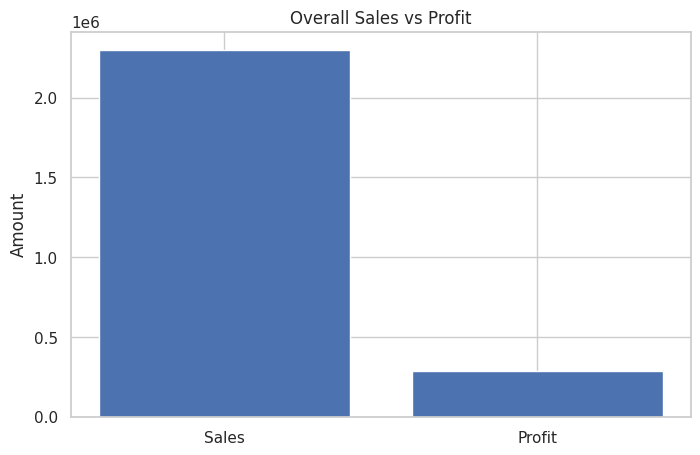

In [64]:
plt.figure(figsize=(8, 5))

metrics = ['Sales', 'Profit']
values = [total_sales, total_profit]

plt.bar(metrics, values)

plt.title('Overall Sales vs Profit')
plt.ylabel('Amount')

plt.show()

### 15.2 Sales & Profit Margin by Category

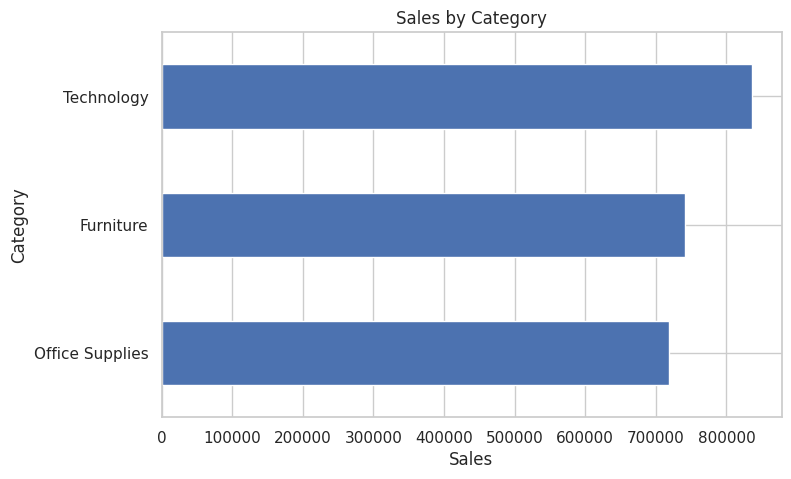

In [65]:
plt.figure(figsize=(8, 5))

category_sales.sort_values().plot(kind='barh')

plt.title('Sales by Category')
plt.xlabel('Sales')
plt.ylabel('Category')

plt.show()

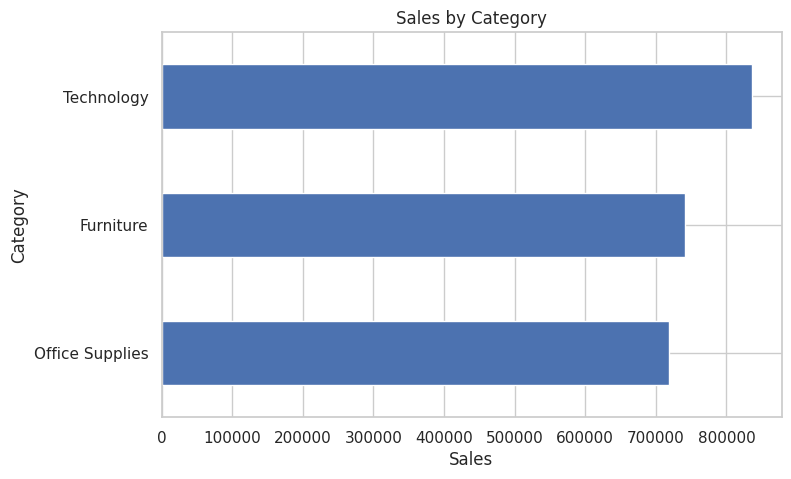

In [66]:
plt.figure(figsize=(8, 5))

category_sales.sort_values().plot(kind='barh')

plt.title('Sales by Category')
plt.xlabel('Sales')
plt.ylabel('Category')

plt.show()

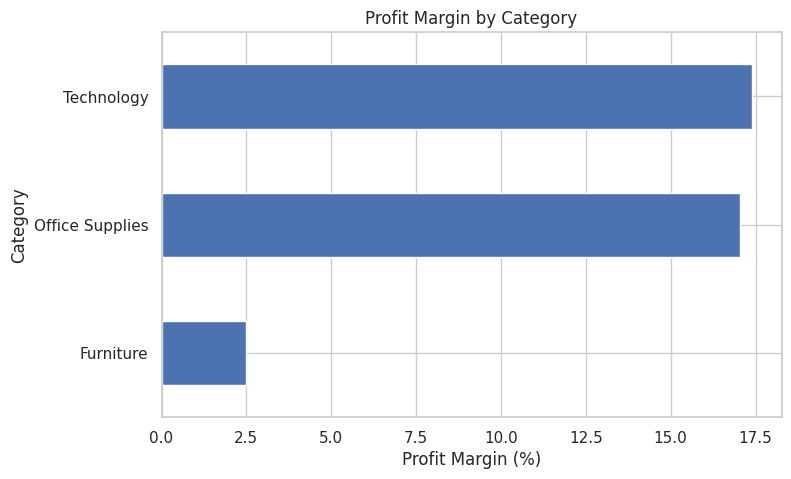

In [67]:
plt.figure(figsize=(8, 5))

category_analysis['Profit Margin %'].sort_values().plot(kind='barh')

plt.title('Profit Margin by Category')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Category')

plt.show()

### 15.3 Sales & Profit by Sub-Category

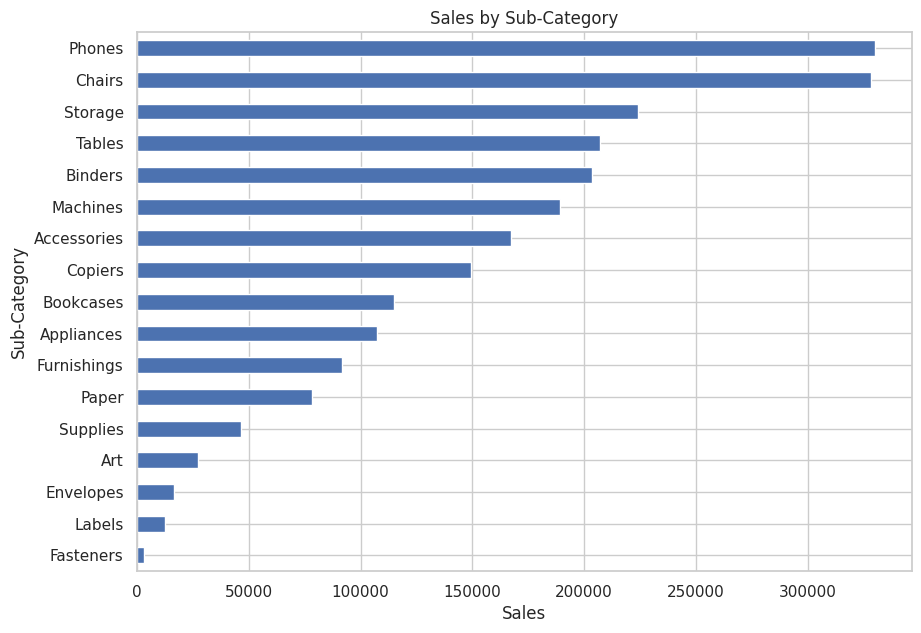

In [68]:
plt.figure(figsize=(10, 7))

subcategory_analysis['Sales'].sort_values().plot(kind='barh')

plt.title('Sales by Sub-Category')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')

plt.show()

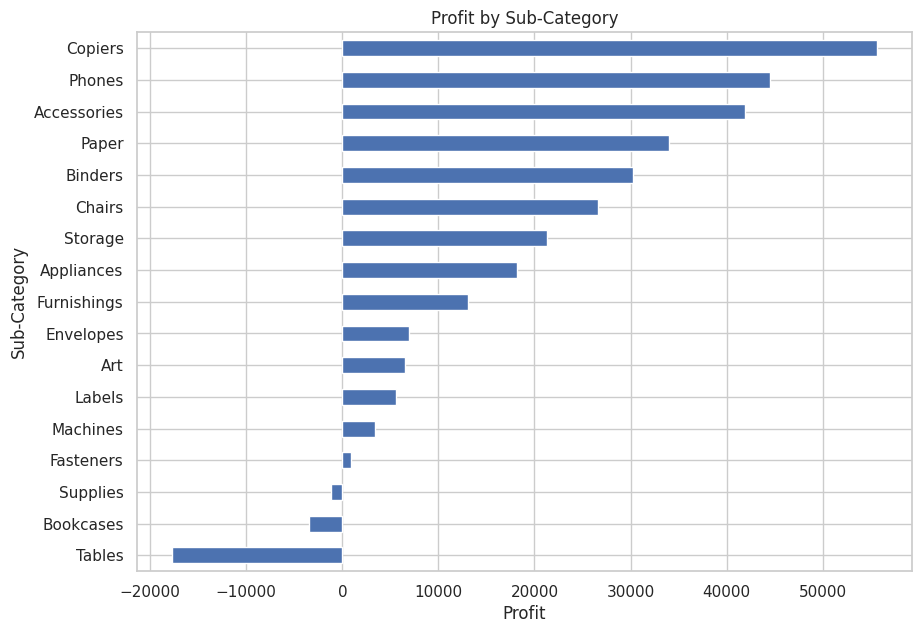

In [69]:
plt.figure(figsize=(10, 7))

subcategory_analysis['Profit'].sort_values().plot(kind='barh')

plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')

plt.show()

### 15.4 Top & Bottom Performing Products

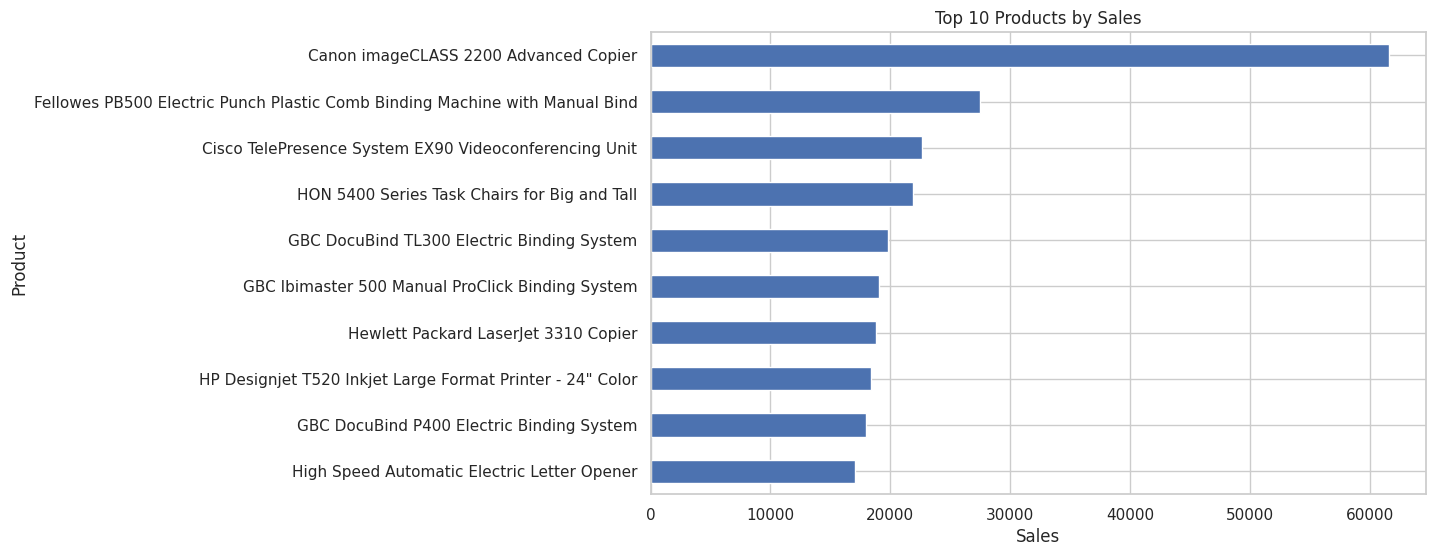

In [70]:
top_products_sales = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))

top_products_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')

plt.show()

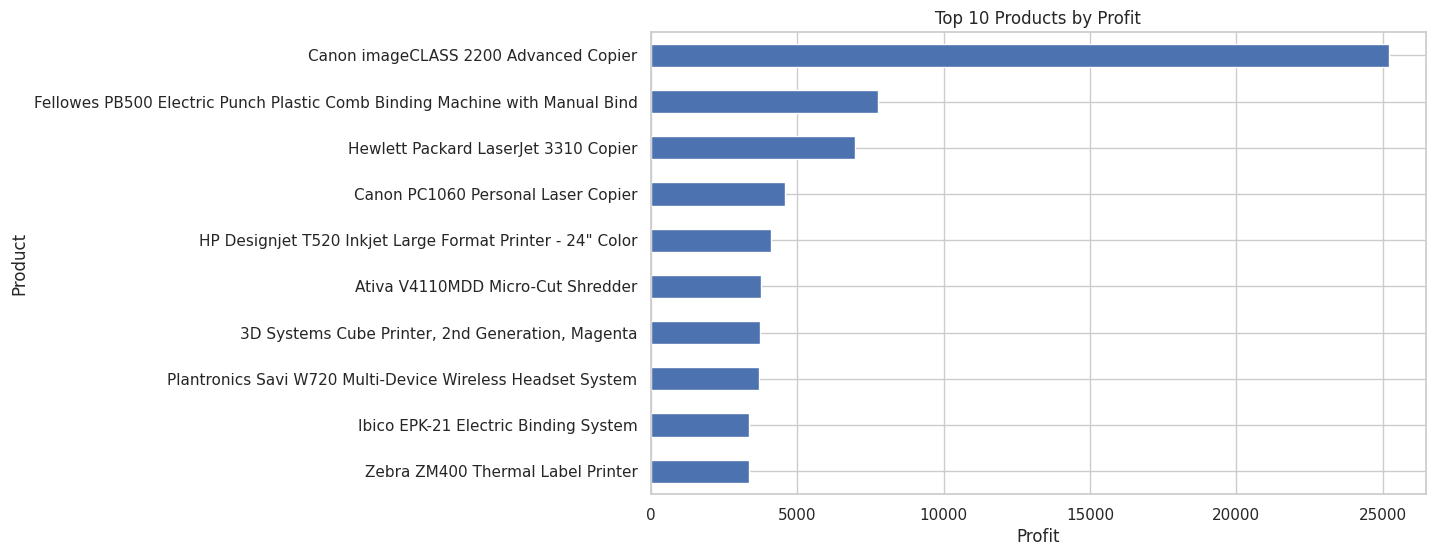

In [71]:
top_products_profit = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))

top_products_profit.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.show()

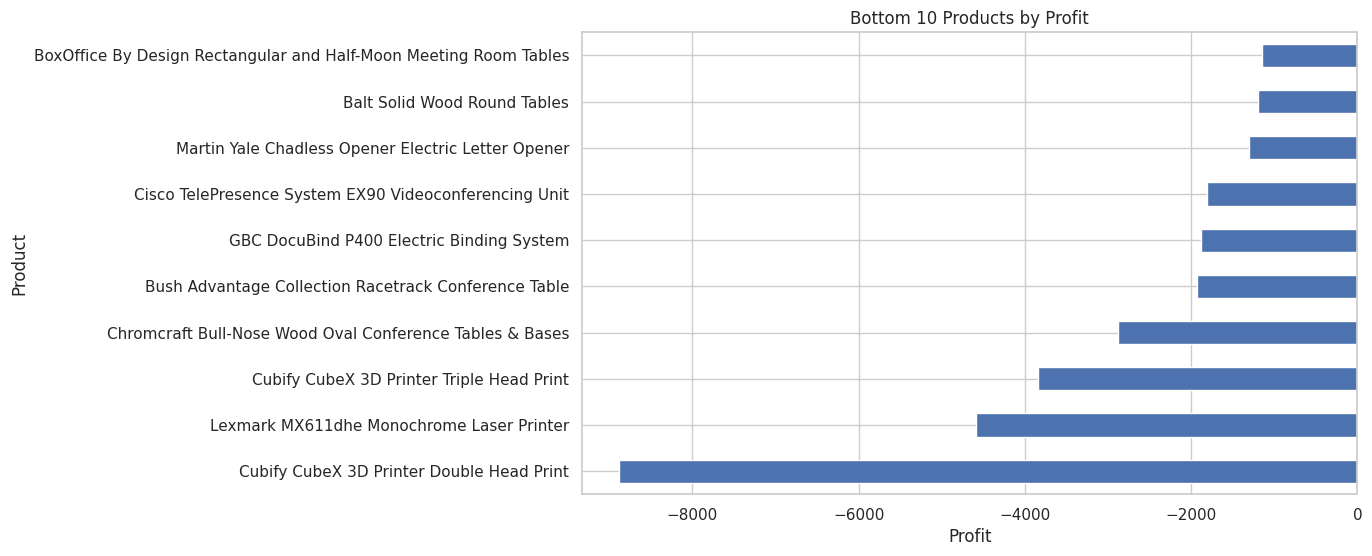

In [72]:
bottom_products_profit = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

plt.figure(figsize=(10, 6))

bottom_products_profit.plot(kind='barh')

plt.title('Bottom 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.show()

### 15.5 Regional Performance

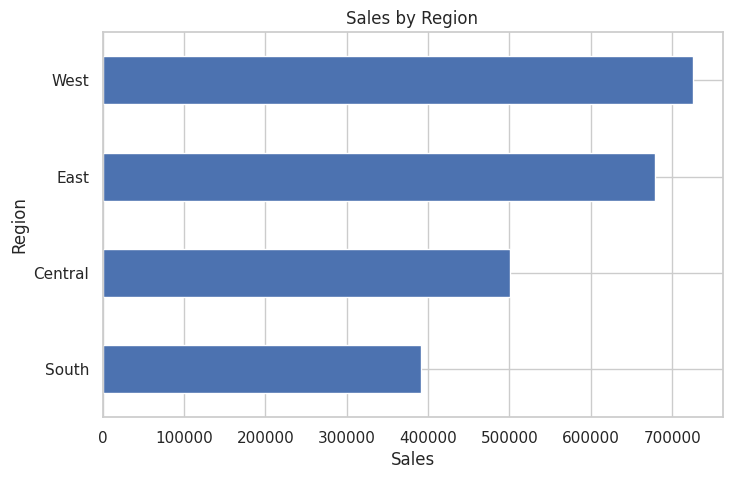

In [73]:
plt.figure(figsize=(8, 5))

region_analysis['Sales'].sort_values().plot(kind='barh')

plt.title('Sales by Region')
plt.xlabel('Sales')
plt.ylabel('Region')

plt.show()

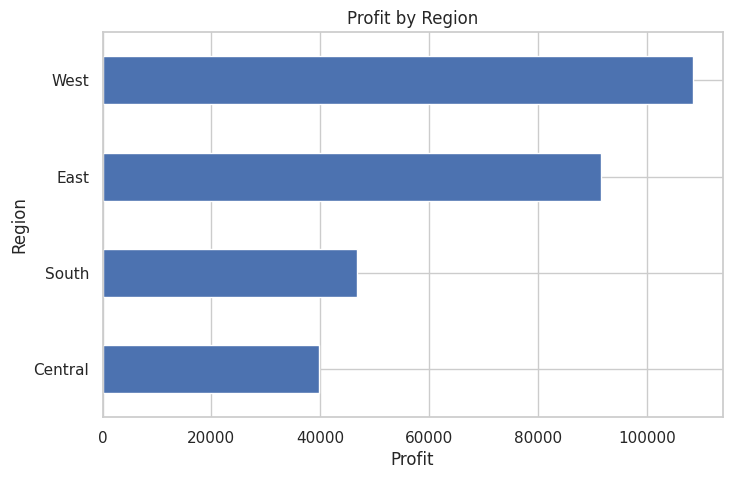

In [74]:
plt.figure(figsize=(8, 5))

region_analysis['Profit'].sort_values().plot(kind='barh')

plt.title('Profit by Region')
plt.xlabel('Profit')
plt.ylabel('Region')

plt.show()

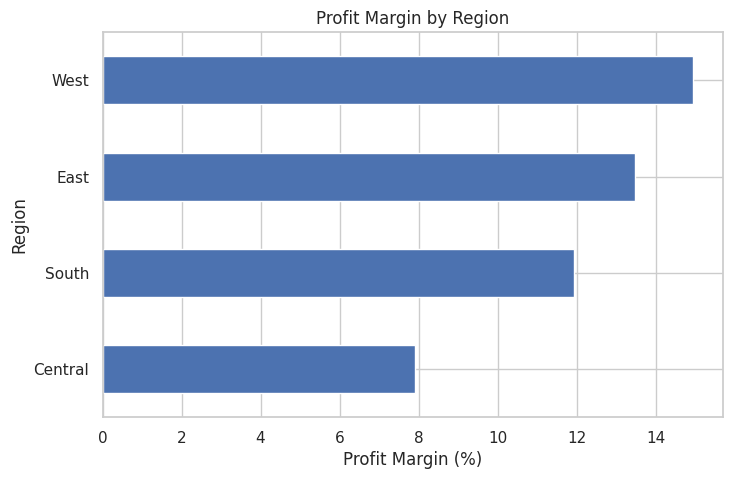

In [75]:
plt.figure(figsize=(8, 5))

region_analysis['Profit Margin %'].sort_values().plot(kind='barh')

plt.title('Profit Margin by Region')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Region')

plt.show()

### 15.6 Sales by Customer Segment

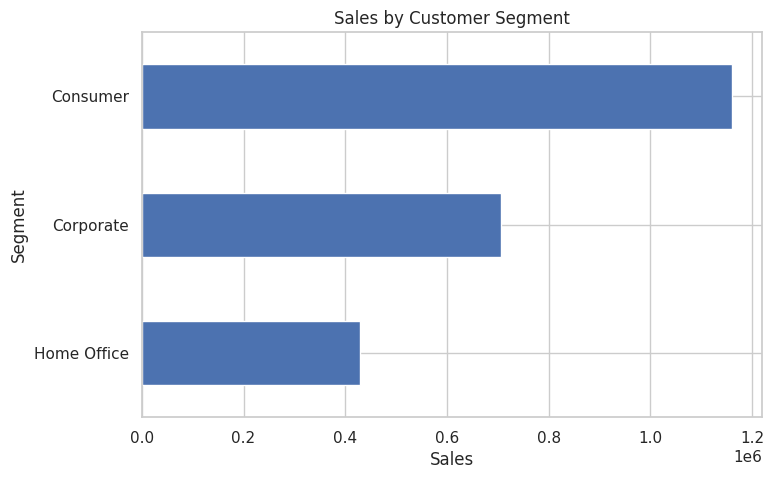

In [76]:
plt.figure(figsize=(8, 5))

segment_analysis['Sales'].sort_values().plot(kind='barh')

plt.title('Sales by Customer Segment')
plt.xlabel('Sales')
plt.ylabel('Segment')

plt.show()

### 15.7 Yearly Sales & Profit Trends

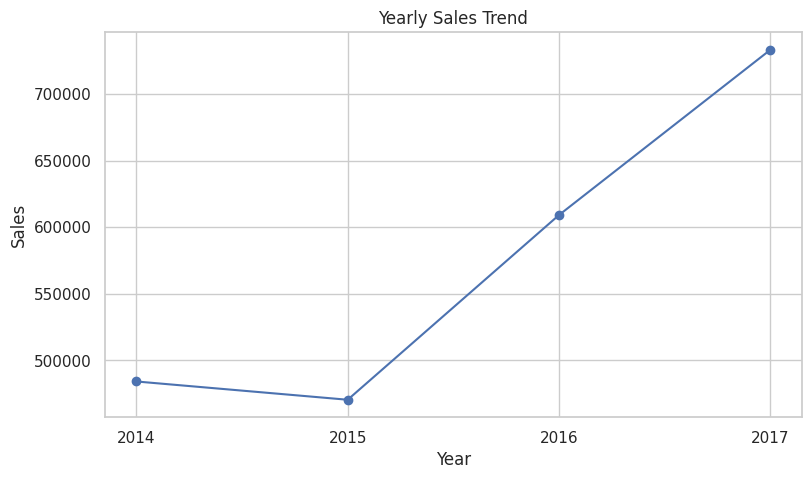

In [77]:
plt.figure(figsize=(9, 5))

plt.plot(
    yearly_analysis.index,
    yearly_analysis['Sales'],
    marker='o'
)

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.xticks(yearly_analysis.index)

plt.show()

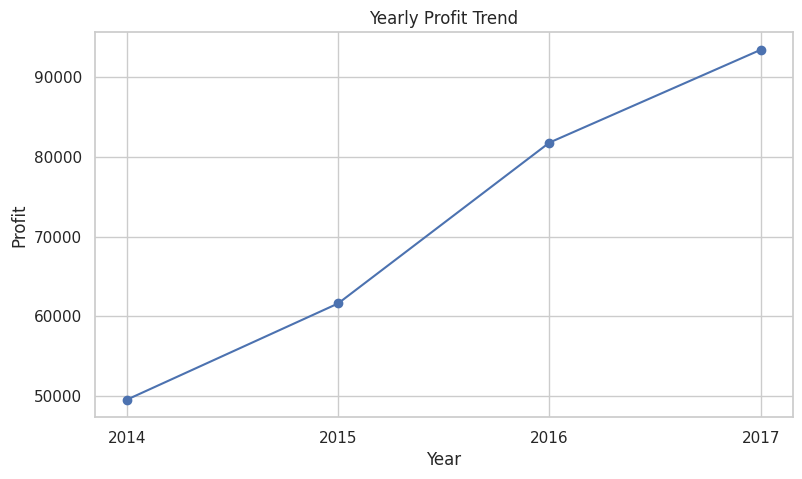

In [78]:
plt.figure(figsize=(9, 5))

plt.plot(
    yearly_analysis.index,
    yearly_analysis['Profit'],
    marker='o'
)

plt.title('Yearly Profit Trend')
plt.xlabel('Year')
plt.ylabel('Profit')

plt.xticks(yearly_analysis.index)

plt.show()

### 15.8 Monthly Sales & Profit Trends

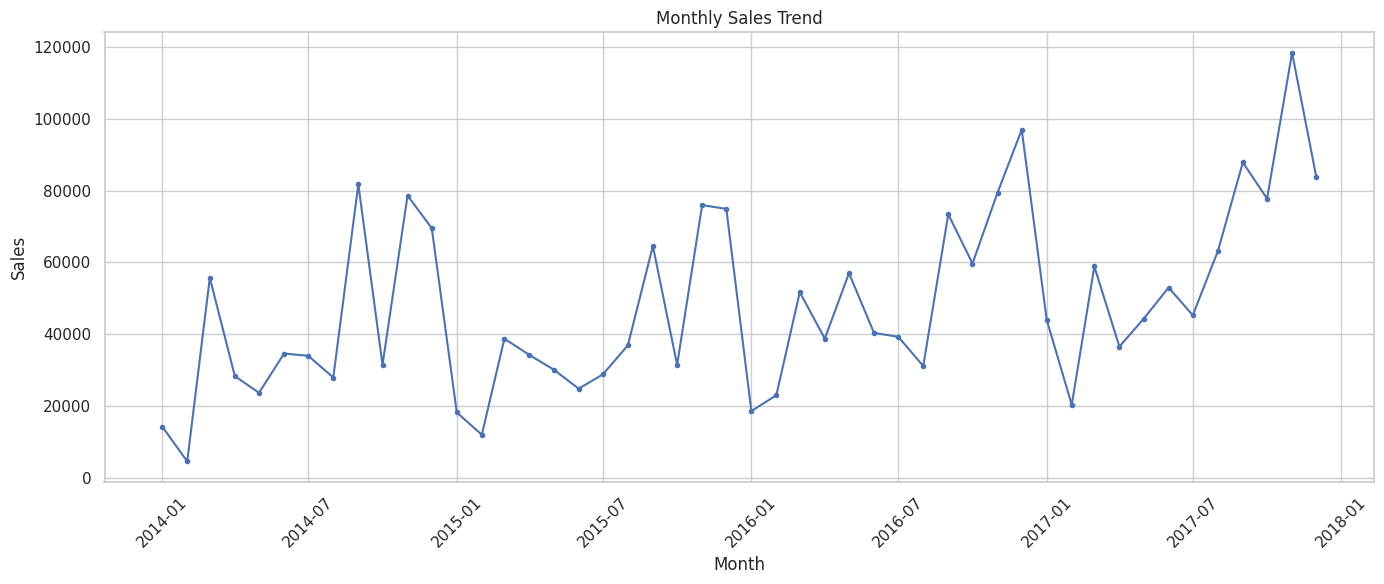

In [79]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    markersize=3
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

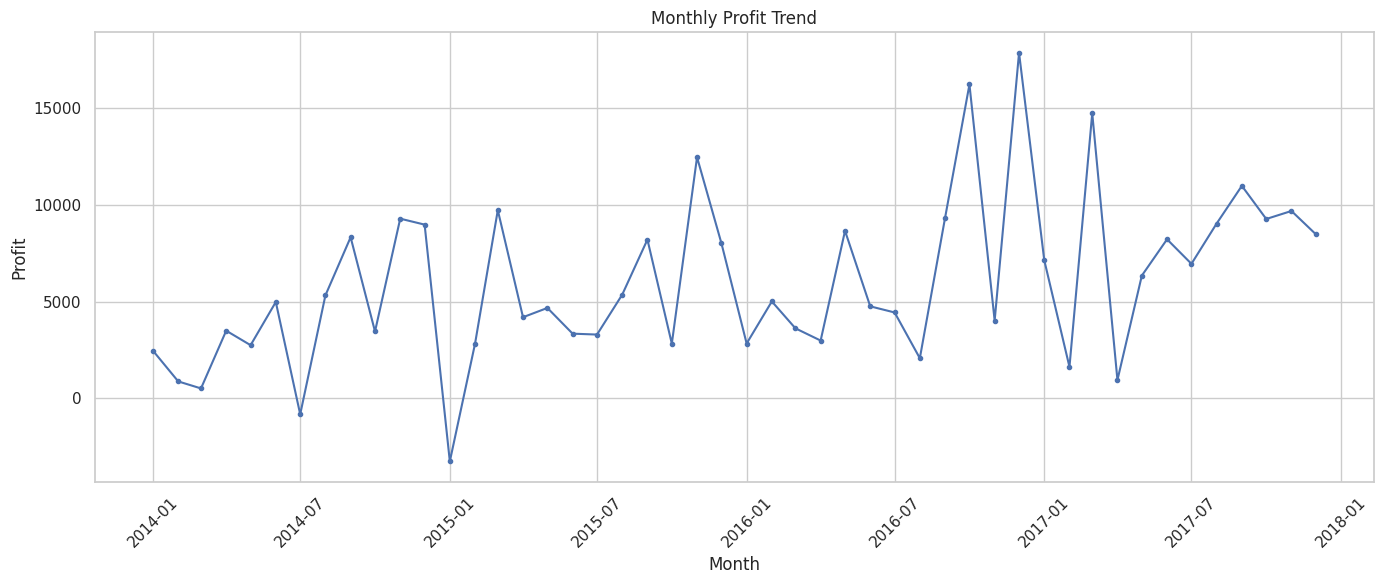

In [80]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker='o',
    markersize=3
)

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 15.9 Quarterly Sales & Profit Trends

In [81]:
quarterly_analysis['Quarter Label'] = (
    quarterly_analysis['Order Year'].astype(str)
    + '-Q'
    + quarterly_analysis['Order Quarter'].astype(str)
)

quarterly_analysis

,Order Year,Order Quarter,Sales,Profit,Quantity,Quarter Label
0,2014,1,74447.7960,3811.2290,1028,2014-Q1
1,2014,2,86538.7596,11204.0692,1523,2014-Q2
2,2014,3,143633.2123,12804.7218,2159,2014-Q3
3,2014,4,179627.7302,21723.9541,2871,2014-Q4
4,2015,1,68851.7386,9264.9416,990,2015-Q1
5,2015,2,89124.1870,12190.9224,1604,2015-Q2
6,2015,3,130259.5752,16853.6194,2241,2015-Q3
7,2015,4,182297.0082,23309.1203,3144,2015-Q4
8,2016,1,93237.1810,11441.3708,1243,2016-Q1
9,2016,2,136082.3010,16390.3394,2240,2016-Q2


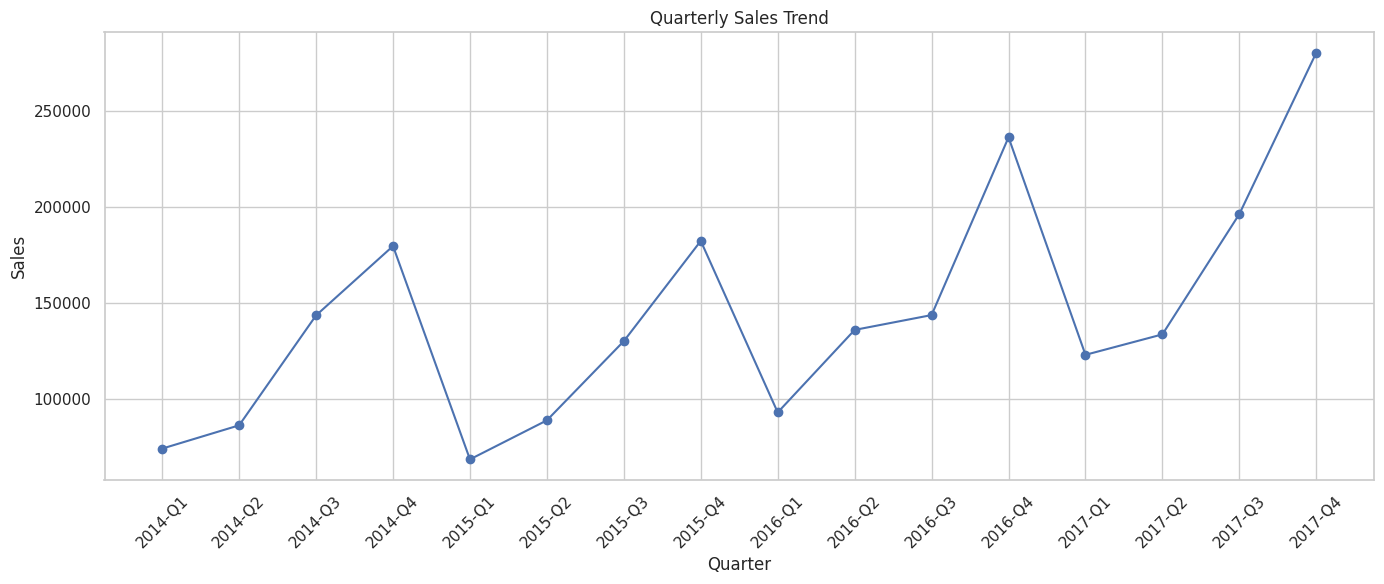

In [82]:
plt.figure(figsize=(14, 6))

plt.plot(
    quarterly_analysis['Quarter Label'],
    quarterly_analysis['Sales'],
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

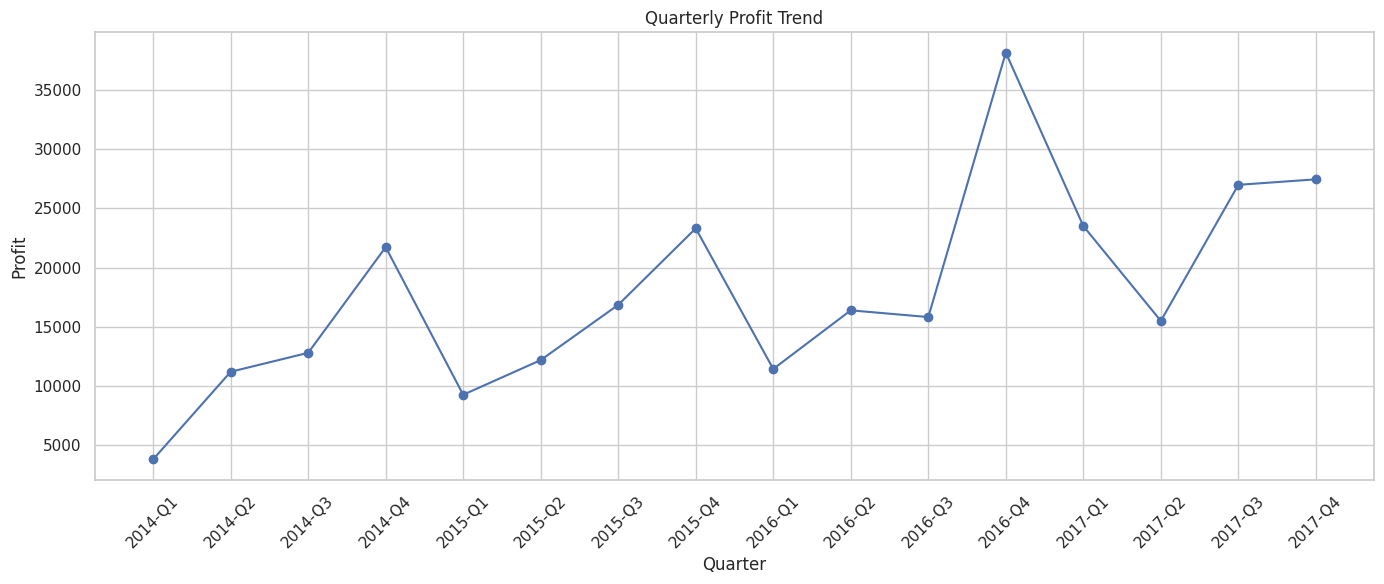

In [83]:
plt.figure(figsize=(14, 6))

plt.plot(
    quarterly_analysis['Quarter Label'],
    quarterly_analysis['Profit'],
    marker='o'
)

plt.title('Quarterly Profit Trend')
plt.xlabel('Quarter')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 15.10 Discount vs Profit

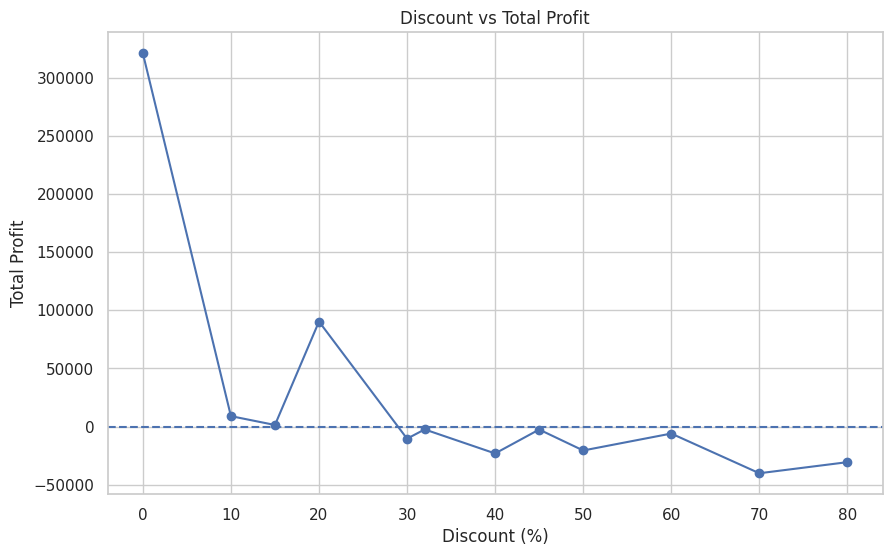

In [84]:
discount_profit = (
    df.groupby('Discount')['Profit']
      .sum()
)

plt.figure(figsize=(10, 6))

plt.plot(
    discount_profit.index * 100,
    discount_profit.values,
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.title('Discount vs Total Profit')
plt.xlabel('Discount (%)')
plt.ylabel('Total Profit')

plt.show()

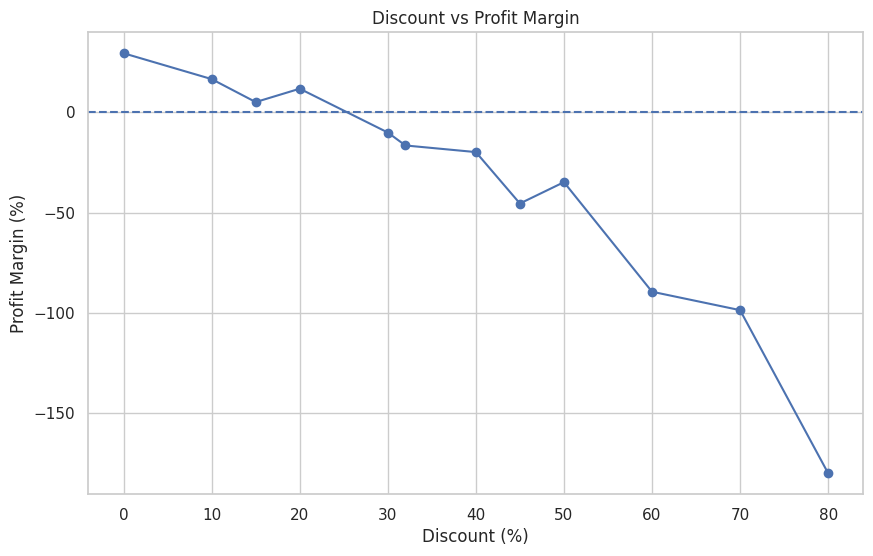

In [85]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_analysis.index * 100,
    discount_analysis['Profit Margin %'],
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.title('Discount vs Profit Margin')
plt.xlabel('Discount (%)')
plt.ylabel('Profit Margin (%)')

plt.show()

### 15.11 Shipping Duration Analysis

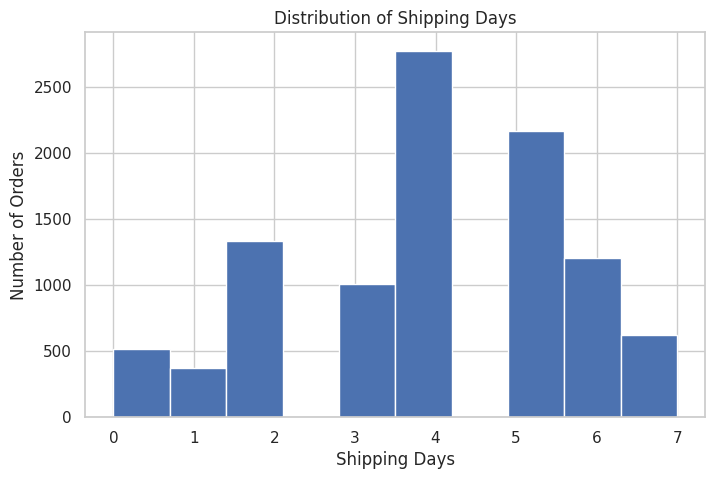

In [86]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['Shipping Days'],
    bins=10
)

plt.title('Distribution of Shipping Days')
plt.xlabel('Shipping Days')
plt.ylabel('Number of Orders')

plt.show()

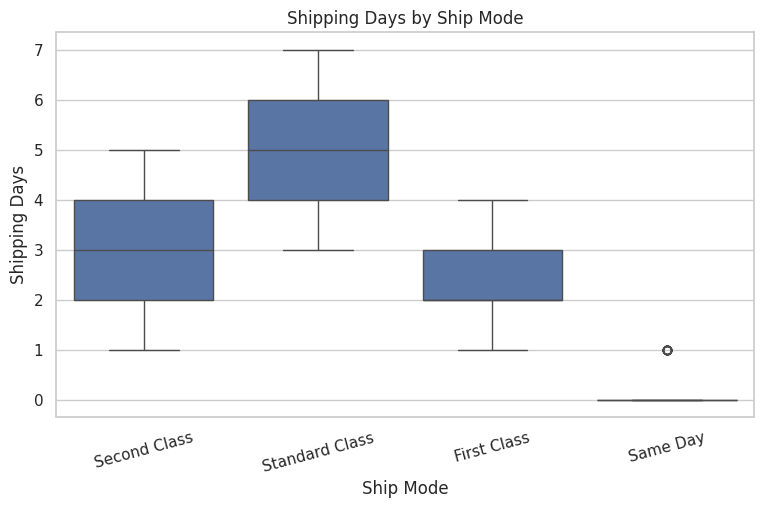

In [87]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Ship Mode',
    y='Shipping Days'
)

plt.title('Shipping Days by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Shipping Days')

plt.xticks(rotation=15)

plt.show()

### 15.12 Sales vs Profit & Discount vs Profit (Scatter)

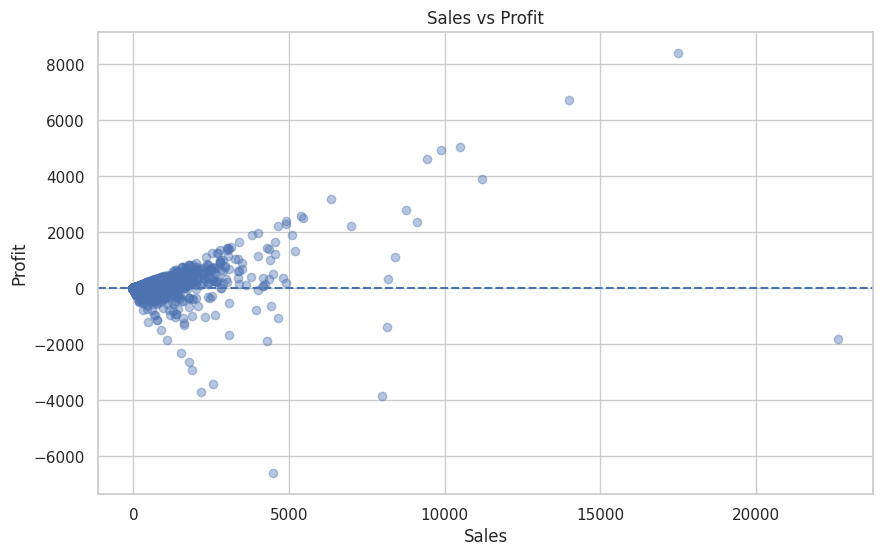

In [88]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Sales'],
    df['Profit'],
    alpha=0.4
)

plt.axhline(0, linestyle='--')

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()

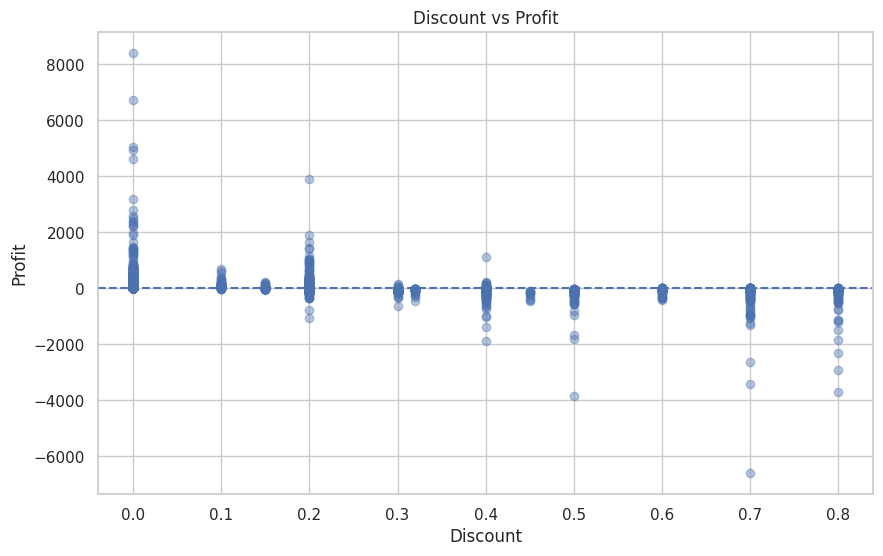

In [89]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.4
)

plt.axhline(0, linestyle='--')

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

## 16. Correlation Analysis

In [90]:
numeric_columns = [
    'Sales',
    'Quantity',
    'Discount',
    'Profit',
    'Shipping Days'
]

correlation = df[numeric_columns].corr()

correlation

,Sales,Quantity,Discount,Profit,Shipping Days
Sales,1.000000,0.200795,-0.028190,0.479064,-0.007354
Quantity,0.200795,1.000000,0.008623,0.066253,0.018298
Discount,-0.028190,0.008623,1.000000,-0.219487,0.000408
Profit,0.479064,0.066253,-0.219487,1.000000,-0.004649
Shipping Days,-0.007354,0.018298,0.000408,-0.004649,1.000000


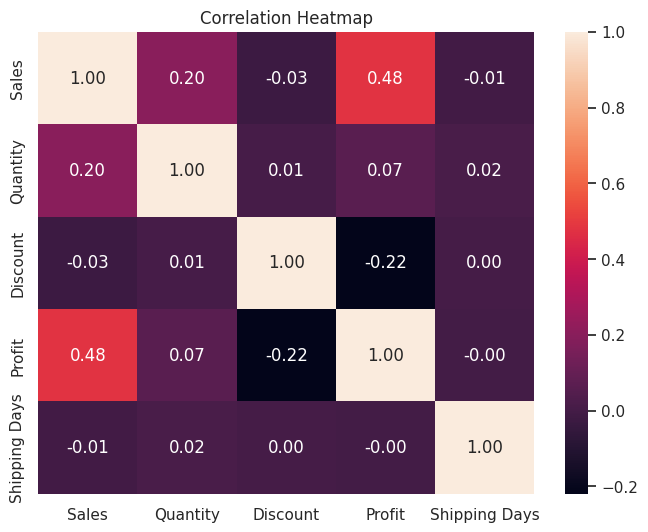

In [91]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## 17. Key Findings & Recommendations

**Key Findings**
- Technology and Office Supplies lead in profitability, while certain Sub-Categories (e.g. Tables, Bookcases) are consistently loss-making.
- Profit margin declines sharply as discount rate increases — high discounts (>30–40%) are strongly associated with negative profit.
- The West and East regions generate the strongest sales and profit; some states are consistently unprofitable despite decent sales volume.
- Standard Class is the most-used shipping mode but has the longest average shipping duration; Same Day is fastest but least used.
- Sales show clear seasonality, with Q4 (Oct–Dec) consistently the strongest quarter each year.

**Recommendations**
1. Re-evaluate or cap discounting on loss-making sub-categories, especially at rates above ~30%.
2. Investigate pricing/cost structure for chronically unprofitable states and sub-categories (e.g. Tables, Bookcases, Supplies).
3. Double down on marketing/inventory for Q4 seasonal demand.
4. Review shipping cost/service tradeoffs for Standard Class given its volume and duration.
5. Prioritize retention and upsell strategies for high-margin categories (Technology, Copiers, Accessories).
